## K-Nearest Neighbors

You are defined by your neighbors

This model can be used for both classification and regression.

In [140]:
import random
import matplotlib.pyplot as plt
import seaborn as sns
import math
from collections import Counter
import statistics

In [172]:
# Let's consider classification examples

X1 = [random.randint(-4, 4) for i in range(30)]
X2 = [random.randint(-4, 4) for i in range(30)]
y = [random.choice(["apple", "banana"]) for i in range(30)]

In [175]:
y_colors = {"apple": "red", "banana": "yellow"}

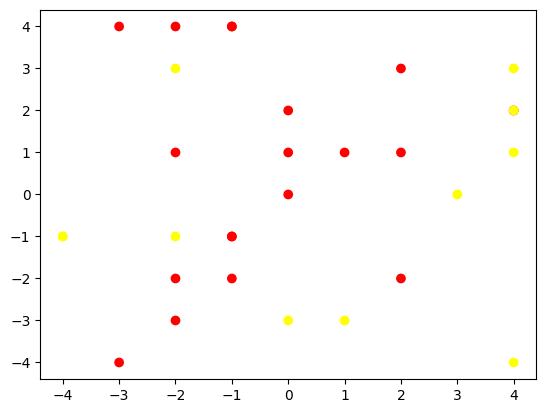

In [176]:
plt.scatter(X1, X2, c=[y_colors[c] for c in y])

In [177]:

class KNN:
    def __init__(self, k, mode="classification"):
        self.k = k
        self.mode = mode

    def train(self, X, y):
        self.X = X
        self.y = y
        return self

    def _distance(self, a, b):
        # can be any distance metric, let's do euclidean for now.
        return math.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)
        
    def predict(self, point):
        distances = {}
        for idx, x in enumerate(self.X):
            dist = self._distance(x, point)
            distances[idx] = dist

        distances = dict(sorted(distances.items(), key=lambda item: item[1])[:self.k])

        close_classes = []
        for k,v in distances.items():
            close_classes.append(self.y[k])

        # for classification, we use max and for reg, we use mean
        if self.mode == "classification":
            c = Counter(close_classes) 
            return c.most_common(1)[0][0]
        else:
            return statistics.mean(close_classes)

### Classification

In [121]:
X = [(x,y) for x,y in zip(X1,X2)]
y = y

In [122]:
model = KNN(k=6, mode="classification")
model.train(X,y)

In [123]:
model.predict((1,1))

'apple'

## Reg

In [125]:
X = [(x,y) for x,y in zip(X1,X2)]
y = [random.random() for i in range(len(X))]

In [126]:
model = KNN(k=6, mode="regression")
model.train(X,y)

In [127]:
model.predict((1,1))

0.40510339846840326